### Derives sensor-specific band magnitudes preparing for cloud simulation with SatelliteCloudGenerator

Link to generator tool: https://github.com/strath-ai/SatelliteCloudGenerator (Czerkawski (2023))

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import rasterio as rio

from src import *

plt.rcParams["figure.figsize"] = (20, 10)
GPU_IDX = 0


def show(tensor, *args, **kwargs):
    while len(tensor.shape) > 3:
        tensor = tensor[0]
    plt.imshow(tensor.permute(1, 2, 0).detach().cpu(), *args, **kwargs)

In [3]:
import imageio

rgb_img = imageio.imread("imgs/rgb_example.png")[..., :3] / 255

# to tensor (B,C,H,W)
rgb_img = torch.FloatTensor(rgb_img).permute(2, 0, 1)

In [4]:
b_img = rgb_img.expand(4, 3, 256, 256)
cl, cmask, smask = add_cloud_and_shadow(b_img, return_cloud=True)

In [3]:
import matplotlib.pyplot as plt
import torch

In [19]:
sat_name = "s2"

files = Path("finals/clear").glob(f"{sat_name}*.tif")

for f in files:
    with rio.open(f, "r") as f:
        clear = f.read()

files = Path("finals/cloudy").glob(f"{sat_name}*.tif")

for f in files:
    with rio.open(f, "r") as f:
        cloudy = f.read()

files = Path("finals/cloudmask").glob(f"{sat_name}*.tif")

for f in files:
    with rio.open(f, "r") as f:
        mask = f.read()

clear = torch.from_numpy(clear.astype(float))
cloudy = torch.from_numpy(cloudy.astype(float))
mask = torch.from_numpy(mask.astype(float))

print(torch.unique(mask))
# cloudy = torch.permute(cloudy,(1,2,0))
# clear = torch.permute(clear,(1,2,0))
# mask = torch.permute(mask,(1,2,0))
print(cloudy.shape)
print(clear.shape)
print(mask.shape)

tensor([0., 1.], dtype=torch.float64)
torch.Size([6, 101, 114])
torch.Size([6, 101, 114])
torch.Size([1, 101, 114])


In [20]:
# Scaling factors
scaling_factors = {
    "s2": [0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001],
    "s3": [0.00493004, 0.00324118],
    "landsat": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    "modis": [0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001],
    "viirs_fine": [1.0, 1.0],
    "viirs_coarse": [1.0, 1.0, 1.0, 1.0],
}

In [21]:
# apply scaling factors
clear_clone = clear.clone()
cloudy_clone = cloudy.clone()

clear = clear_clone * torch.tensor(scaling_factors[sat_name]).float().view(-1, 1, 1)
cloudy = cloudy_clone * torch.tensor(scaling_factors[sat_name]).float().view(-1, 1, 1)

tensor(0.0059, dtype=torch.float64)
tensor(0.6020, dtype=torch.float64)


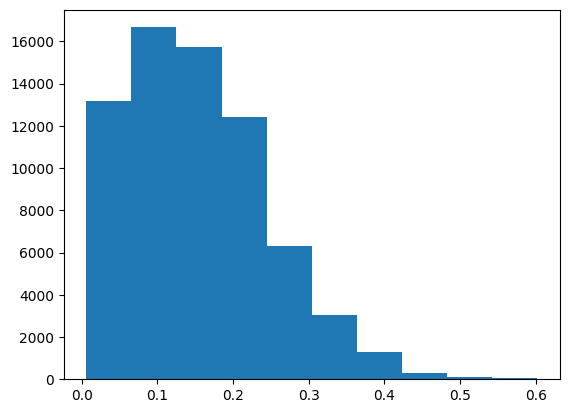

In [22]:
plt.hist(clear.flatten())

print(clear.min())
print(clear.max())

(array([ 7687.,  8842.,  6387., 10135., 11831., 10213.,  7464.,  4411.,
         1790.,   324.]),
 array([0.0514    , 0.09473   , 0.13806   , 0.18139   , 0.22471999,
        0.26804999, 0.31137999, 0.35470999, 0.39803999, 0.44136999,
        0.48469999]),
 <BarContainer object of 10 artists>)

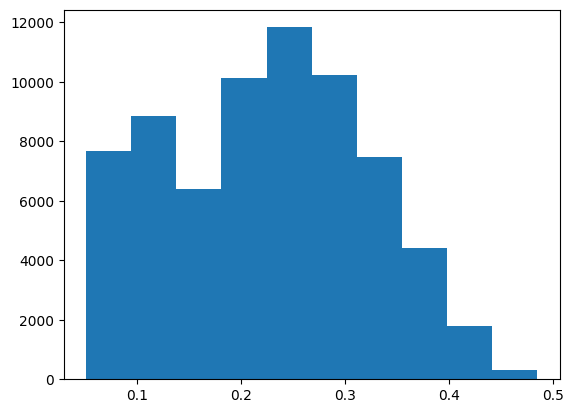

In [23]:
plt.hist(cloudy.flatten())

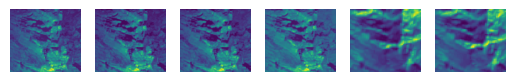

In [24]:
for idx in range(clear.shape[0]):
    plt.subplot(2, 6, 1 + idx)
    plt.imshow(clear[idx])
    plt.axis("off")

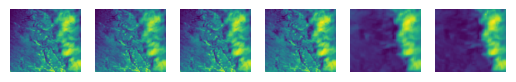

In [25]:
for idx in range(cloudy.shape[0]):
    plt.subplot(2, 6, 1 + idx)
    plt.imshow(cloudy[idx])
    plt.axis("off")

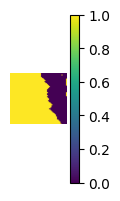

In [26]:
for idx in range(mask.shape[0]):
    plt.subplot(2, 6, 1 + idx)
    plt.imshow(mask[idx])
    plt.axis("off")
    plt.colorbar()

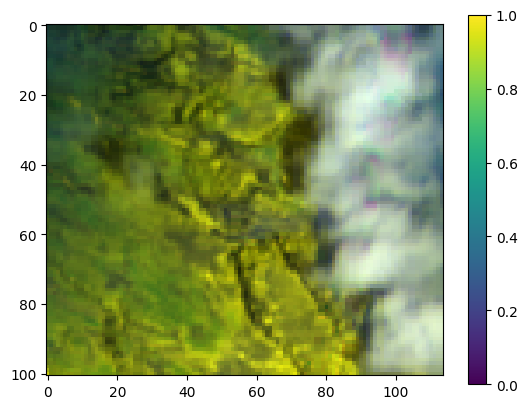

In [27]:
rgb = torch.stack([cloudy[2], cloudy[3], cloudy[4]], axis=0)
rgb_img = (rgb - rgb.min()) / (rgb.max() - rgb.min())
plt.imshow(torch.permute(rgb_img, (1, 2, 0)))
plt.colorbar()

In [28]:
!pip install git+https://github.com/strath-ai/SatelliteCloudGenerator

  Cloning https://github.com/strath-ai/SatelliteCloudGenerator to c:\users\marle\appdata\local\temp\pip-req-build-04g9zqni
  Resolved https://github.com/strath-ai/SatelliteCloudGenerator to commit d0787cbdc1b39a7976f89aa085f1430f3207eda6
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached kornia-0.8.2-py2.py3-none-any.whl.metadata (18 kB)
Using cached kornia-0.8.2-py2.py3-none-any.whl (1.1 MB)
   ---------------------------------------- 0.0/3.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.4/3.4 MB 8.3 MB/s eta 0:00:01
   ---------------- ----------------------- 1.4/3.4 MB 15.0 MB/s eta 0:00:01
   ---------------------------- ----------- 2.5/3.4 MB 17.4 MB/s eta 0:00:01
   ---------------------------------------  3.4/3.4 MB 18.0 MB/s eta 0:00:01
   ---------------------------------------- 3.4/3.4 MB 15.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/122.9 MB ? eta -:--:--
   -----------

  Running command git clone --filter=blob:none --quiet https://github.com/strath-ai/SatelliteCloudGenerator 'C:\Users\marle\AppData\Local\Temp\pip-req-build-04g9zqni'
  You can safely remove it manually.


In [ ]:
import satellite_cloud_generator.band_magnitudes as band_mg

In [ ]:
cmags = band_mg.q_mag(
    cloudy, mask=mask == 1.0, mask_cloudy=mask == 0.0, clean=clear, q=0.95, q2=0.5
)
print(cmags)